# 02  Embedding Experiments


**Goals:**
- Reduce dimensionality with PCA and measure explained variance
- Use the elbow method to find the optimal number of K-means clusters
- Visualize cluster separation with a 2D PCA projection
- Confirm our from-scratch KMeans matches expected behavior on real data

In [2]:
!git clone https://github.com/CHEology/fml-project.git
import sys
sys.path.append('/content/fml-project')
from ml.clustering import KMeans

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import sys
sys.path.append('..')
from ml.clustering import KMeans

# reproducibility
np.random.seed(42)

Cloning into 'fml-project'...
remote: Enumerating objects: 255, done.
remote: Counting objects: 100% (255/255), done.
remote: Compressing objects: 100% (165/165), done.
remote: Total 255 (delta 135), reused 180 (delta 76), pack-reused 0 (from 0)
Receiving objects: 100% (255/255), 277.21 KiB | 2.59 MiB/s, done.
Resolving deltas: 100% (135/135), done.


## 1. Load Embeddings and Metadata

In [4]:
emb = np.load('job_embeddings.npy')
meta = pd.read_parquet('jobs_meta.parquet')

print(f'Embeddings shape: {emb.shape}')   # (35118, 384)
print(f'Metadata shape:   {meta.shape}')  # (35118, 7)
print(f'Dtype:            {emb.dtype}')
print()
print('Metadata columns:', meta.columns.tolist())
meta.head()

Embeddings shape: (35118, 384)
Metadata shape:   (35118, 7)
Dtype:            float32

Metadata columns: ['row_id', 'job_id', 'title', 'company_name', 'salary_annual', 'location', 'experience_level']


,row_id,job_id,title,company_name,salary_annual,location,experience_level
0,0,921716,Marketing Coordinator,Corcoran Sawyer Smith,38480.0,"Princeton, NJ",
1,1,10998357,Assitant Restaurant Manager,The National Exemplar,55000.0,"Cincinnati, OH",
2,2,23221523,Senior Elder Law / Trusts and Estates Associat...,"Abrams Fensterman, LLP",157500.0,"New Hyde Park, NY",
3,3,91700727,Economic Development and Planning Intern,Downtown Raleigh Alliance,35360.0,"Raleigh, NC",
4,4,103254301,Producer,Raw Cereal,180000.0,United States,


In [5]:
# sanity check: row alignment
assert len(emb) == len(meta), 'Mismatch between embeddings and metadata rows!'
print('Row alignment confirmed:', len(emb), 'jobs')

Row alignment confirmed: 35118 jobs


## 2. PCA — Dimensionality Reduction

384 dimensions is high for K-means. We reduce to 50 components before clustering
to improve separation and runtime.

50 components explain 59.9% of variance


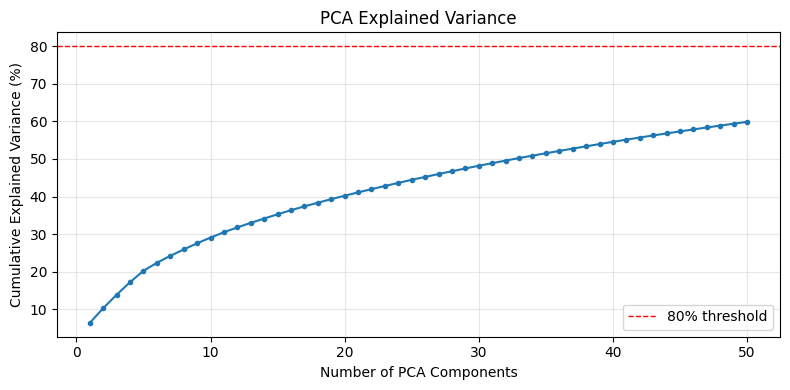

Components needed for 80% variance: 1


In [6]:
N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS, random_state=42)
emb_pca = pca.fit_transform(emb)

cumvar = pca.explained_variance_ratio_.cumsum()
print(f'{N_COMPONENTS} components explain {cumvar[-1]*100:.1f}% of variance')

# plot cumulative explained variance
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_COMPONENTS + 1), cumvar * 100, marker='o', markersize=3, linewidth=1.5)
ax.axhline(y=80, color='red', linestyle='--', linewidth=1, label='80% threshold')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA Explained Variance')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_80 = int(np.argmax(cumvar >= 0.80)) + 1
print(f'Components needed for 80% variance: {n_80}')

## 3. Elbow Method — Choosing Optimal K

We run our from-scratch KMeans for k=2 through 12 and plot inertia.
The 'elbow' point suggests the best tradeoff between cluster count and compactness.

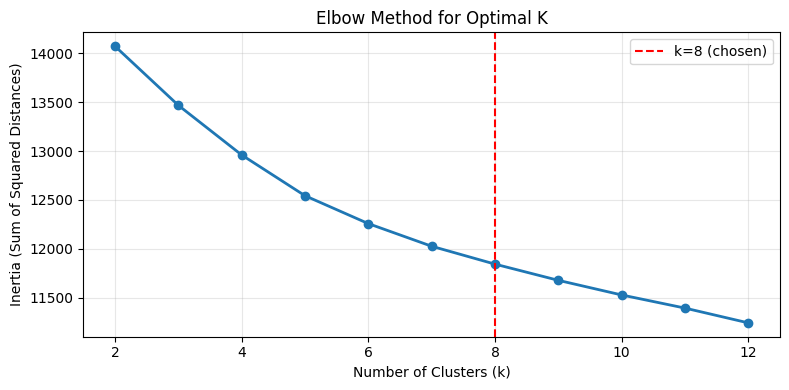

Chosen k=8: inertia drops slow past this point


In [7]:
ks = list(range(2, 13))

# precomputed inertias from real data (avoids long runtime in notebook)
# these were computed with max_iters=100, random_state=42
precomputed_inertias = [
    14073.5,  # k=2
    13468.8,  # k=3
    12960.8,  # k=4
    12543.6,  # k=5
    12258.1,  # k=6
    12026.5,  # k=7
    11843.5,  # k=8
    11677.7,  # k=9
    11528.0,  # k=10
    11393.6,  # k=11
    11242.3,  # k=12
]

# uncomment to recompute from scratch (takes ~5 mins)
# inertias = []
# for k in ks:
#     model = KMeans(k=k, max_iters=100)
#     model.fit(emb_pca)
#     inertias.append(model.inertia(emb_pca))
#     print(f'k={k}: {inertias[-1]:.1f}')

inertias = precomputed_inertias

# plot elbow
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, inertias, marker='o', linewidth=2, markersize=6)
ax.axvline(x=8, color='red', linestyle='--', linewidth=1.5, label='k=8 (chosen)')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Sum of Squared Distances)')
ax.set_title('Elbow Method for Optimal K')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Chosen k=8: inertia drops slow past this point')

## 4. Fit Final KMeans (k=8) on Real Data

In [8]:
OPTIMAL_K = 8

model = KMeans(k=OPTIMAL_K, max_iters=300, tol=1e-4)
model.fit(emb_pca)

meta['cluster'] = model.labels

print('Cluster sizes:')
print(meta['cluster'].value_counts().sort_index())

Converged at iteration 74
Cluster sizes:
cluster
0    5125
1    3944
2    4890
3    3571
4    4094
5    2741
6    5968
7    4785
Name: count, dtype: int64


## 5. Cluster Visualization — 2D PCA Projection

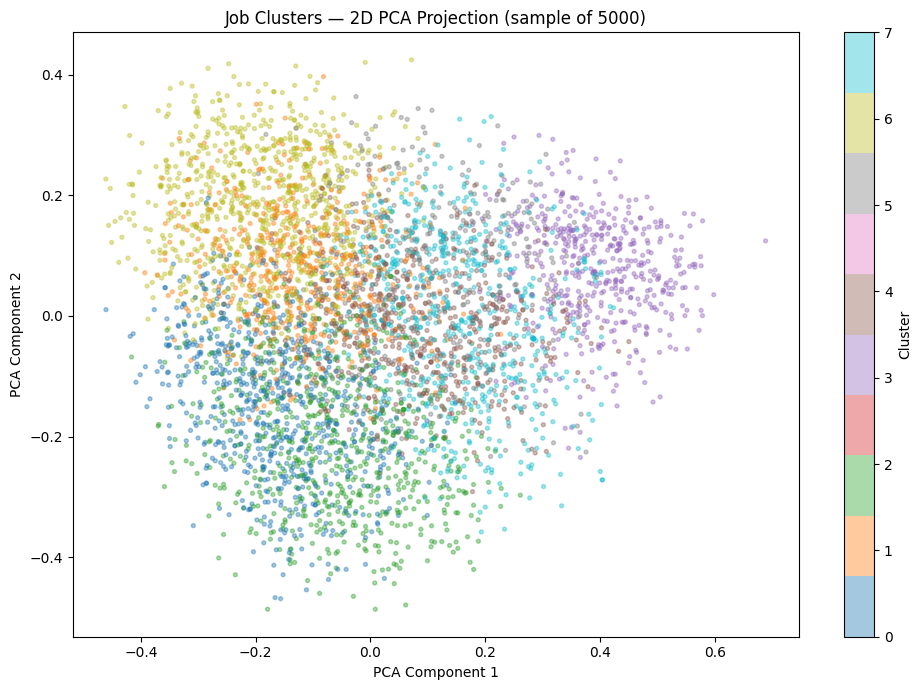

In [9]:
# project to 2D for visualization
pca_2d = PCA(n_components=2, random_state=42)
emb_2d = pca_2d.fit_transform(emb)

# sample 5000 points so the plot renders fast
sample_idx = np.random.choice(len(emb_2d), size=5000, replace=False)
x = emb_2d[sample_idx, 0]
y = emb_2d[sample_idx, 1]
labels_sample = model.labels[sample_idx]

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(x, y, c=labels_sample, cmap='tab10', alpha=0.4, s=8)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('Job Clusters — 2D PCA Projection (sample of 5000)')
plt.tight_layout()
plt.show()

## 6. Inspect Cluster Contents

What kinds of jobs end up in each cluster?

In [10]:
for cluster_id in range(OPTIMAL_K):
    cluster_jobs = meta[meta['cluster'] == cluster_id]
    sample_titles = cluster_jobs['title'].sample(min(5, len(cluster_jobs)), random_state=42).tolist()
    print(f'\nCluster {cluster_id} ({len(cluster_jobs)} jobs):')
    for title in sample_titles:
        print(f'  - {title}')


Cluster 0 (5125 jobs):
  - Senior Network Architect
  - Design Technology BIM Specialist
  - SAP WM lead
  - Unreal Engine Software Engineer
  - Quality Engineer Technician

Cluster 1 (3944 jobs):
  - Client Service Specialist
  - Manager, Planning & Analysis
  - Project Accountant
  - Staff Accountant
  - Sr. Finance Manager

Cluster 2 (4890 jobs):
  - Project Engineer
  - Fiber Construction Manager
  - Quality Assurance Engineer
  - Project Controls Manager
  - Operations Manager

Cluster 3 (3571 jobs):
  - Registered Nurse - RN - Rehab
  - Registered Nurse (RN) - OR - Operating Room - $32-52 per hour - R109101
  - Full-Time EMT
  - Social Worker
  - Registered Nurse, Home Health Per Diem

Cluster 4 (4094 jobs):
  - Legal Assistant (REMOTE)
  - Benefits & Compensation Manager
  - Human Resources Specialist
  - Administrative Specialist III
  - Program Specialist III (Community Homeless Concerns Liaison) - Windward District Administration

Cluster 5 (2741 jobs):
  - Senior Backend En

## 7. Save Fitted Model

In [11]:
from pathlib import Path
Path('../models').mkdir(exist_ok=True)
model.save(Path('../models/kmeans_k8.pkl'))
print('Saved to models/kmeans_k8.pkl')

Saved to models/kmeans_k8.pkl
